# Fresh start of notebook cleaning

In [ ]:
for var in list(globals()):
    if not var.startswith("_") and var not in ["gc"]:
        del globals()[var]

# Imports

In [1]:
import gc
gc.collect()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.options.display.max_columns = 100
pd.options.display.max_rows = 300


In [2]:
def dtypes_opt(df):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    obj_type=['object', 'string']
    
    for col in df.columns:
        col_type = df[col].dtypes
        
        if col=='id':
            df[col]=df[col].astype('object')

        elif col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                       df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type in obj_type:
            df[col] = df[col].astype('category')
    return df

# Load Data

In [ ]:
df_calendar = dtypes_opt(pd.read_csv("../data/calendar.csv", ))
df_sales_validation = dtypes_opt(pd.read_csv("../data/sales_train_validation.csv"))
df_sales_evaluation = dtypes_opt(pd.read_csv("../data/sales_train_evaluation.csv"))
df_prices = dtypes_opt(pd.read_csv("../data/sell_prices.csv"))

# Data Inspection

In [ ]:
df_calendar[df_calendar['wday']==1].head(5)

In [ ]:
df_sales_validation.tail()

In [ ]:
df_sales_evaluation.tail()

In [ ]:
df_prices.head()

In [ ]:
df_calendar.info()

In [ ]:
df_calendar.describe(include='all')

In [ ]:
df_sales_validation.info()

In [ ]:
df_sales_validation.describe(include='all')

In [ ]:
df_sales_evaluation.info()

In [ ]:
df_sales_evaluation.describe(include='all')

In [ ]:
df_prices.info()

In [ ]:
df_prices.describe(include='all')

In [ ]:
df_prices[df_prices['wm_yr_wk'] == 11101]

# Data Merging
at the end we leave a variable: merged_dataset

In [ ]:
# Merge the 3 main datasets into one dataset: sales + calendar + prices.

day_columns = [col for col in df_sales_validation.columns if col.startswith('d_')]
id_columns = [col for col in df_sales_validation.columns if col not in day_columns]

merged_dataset = df_sales_validation.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name='d',
    value_name='sales',
)

merged_dataset = merged_dataset.merge(df_calendar, on='d', how='left')

# With the constraints of inventory, there shouldnt be items withtout a price
# So we do inner merge
merged_dataset = merged_dataset.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='inner')

del day_columns, id_columns
gc.collect()

# merged_dataset.head()

## Freeing Memory

In [ ]:
# Free memory from the base datasets after creating merged_dataset.
del df_sales_validation, df_sales_evaluation, df_calendar, df_prices

gc.collect()

# Data Basic Transformation

In [ ]:
# Change the d column to an int format for better handling.
merged_dataset['d'] = merged_dataset['d'].str[2:].astype('int16')


In [ ]:
merged_dataset['d'].tail()


# Safe feature engineering

Price Change Features

In [ ]:
# Price movement for the same item-store.
merged_dataset = merged_dataset.sort_values(["id", "d"]).copy()
id_price = merged_dataset.groupby("id", observed=True, sort=False)["sell_price"]

merged_dataset['price_change_1'] = id_price.diff(1).fillna(0)
merged_dataset['price_change_7'] = id_price.diff(7).fillna(0)

dtypes_opt(merged_dataset)

del id_price
gc.collect()


merged_dataset[['id', 'date', 'sell_price', 'price_change_1', 'price_change_7']].head(10)

In [ ]:
merged_dataset[['id', 'sell_price', 'price_change_1', 'price_change_7']].head(10)

Date and week removing


In [ ]:
# Models here dont work with strings, so weekday is irrelevent (can be asserted from wday)
# wm_yr_wk has only the week number of the year relevent so we can reduce it to that
# date has only the day - number relevent, so we can reduce it to that

# Calendar string cleanup for model-ready features.
merged_dataset["date"] = pd.to_datetime(merged_dataset['date'])
merged_dataset["day"] = merged_dataset["date"].dt.day
merged_dataset["week"] = merged_dataset["wm_yr_wk"] % 100
merged_dataset["year"] = merged_dataset["year"] - merged_dataset["year"].min() + 1
# Year is just a number, so no need for it to start in 2011, we can just subtract 2011 from it to make it start at 0

merged_dataset.drop(columns=['date', 'weekday', 'wm_yr_wk'], inplace=True)

In [ ]:
merged_dataset[["id", "week", "day", "year", 'sales']].head()

In [ ]:
# Merging SNAP with state
dummy_state = pd.get_dummies(merged_dataset['state_id'], dtype='int8')

merged_dataset['snap'] = (
    merged_dataset['snap_CA'] * dummy_state['CA']
    + merged_dataset['snap_TX'] * dummy_state['TX']
    + merged_dataset['snap_WI'] * dummy_state['WI']
).astype('bool')

merged_dataset.drop(columns=['snap_CA', 'snap_TX', 'snap_WI'], inplace=True)
merged_dataset = dtypes_opt(merged_dataset)

del dummy_state
gc.collect()

In [ ]:
# Keep event one-hot features, and also preserve raw event values for target encoding later.

# merged_dataset = pd.get_dummies(
#     merged_dataset,
#     columns=['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2'],
#     dummy_na=False,
#     dtype="int8"
# )

In [ ]:
# merged_dataset.columns

In [ ]:
# Now we have to transform the numbers to represent their closeness, for example first day of the next month and last day of the first month are close
# same with week and wday and month, we can use sine and cosine to represent this closeness
# well create new features called day_sin and day_cos, and week_sin and week_cos

WDAY_PERIOD = 7
DAY_PERIOD = 31
WEEK_PERIOD = 52
MONTH_PERIOD = 12

merged_dataset = merged_dataset.assign(
    day_sin=lambda df: np.sin(2 * np.pi * df['day'] / DAY_PERIOD).astype('float32'),
    day_cos=lambda df: np.cos(2 * np.pi * df['day'] / DAY_PERIOD).astype('float32'),
    wday_sin=lambda df: np.sin(2 * np.pi * df['wday'] / WDAY_PERIOD).astype('float32'),
    wday_cos=lambda df: np.cos(2 * np.pi * df['wday'] / WDAY_PERIOD).astype('float32'),
    week_sin=lambda df: np.sin(2 * np.pi * df['week'] / WEEK_PERIOD).astype('float32'),
    week_cos=lambda df: np.cos(2 * np.pi * df['week'] / WEEK_PERIOD).astype('float32'),
    month_sin=lambda df: np.sin(2 * np.pi * df['month'] / MONTH_PERIOD).astype('float32'),
    month_cos=lambda df: np.cos(2 * np.pi * df['month'] / MONTH_PERIOD).astype('float32'),
)

merged_dataset.drop(columns=['day', 'wday', 'week', 'month'], inplace=True)

In [ ]:
# merged_dataset.head()

In [ ]:
# one hot
# merged_dataset = pd.get_dummies(
#     merged_dataset,
#     columns=['cat_id', 'dept_id', 'state_id', 'store_id'],
#     dtype='int8'
# )

In [ ]:
# merged_dataset.head()

In [ ]:
merged_dataset.columns

# Splitting Cross Validation
There are 1913 days from d_1 to d_1913
```
cv1: 1-1885, 1886-1913

In [ ]:
# Here we split the merged data set into 1 cv (for now)
# cv1: first (1913-28) days for training, last 28 days for validation

train_cv1 = merged_dataset[merged_dataset['d'] <= 1913 - 28].copy()
test_cv1 = merged_dataset[merged_dataset['d'] > 1913 - 28].copy()


In [ ]:
# printing min and max of train and test:
print(f'Train CV1 min: {train_cv1["d"].min()}')
print(f'Train CV1 max: {train_cv1["d"].max()}')
print(f'Test CV1 min: {test_cv1["d"].min()}')
print(f'Test CV1 max: {test_cv1["d"].max()}')


#  Unsafe Feature Engineering 

## Encoding Functions

In [ ]:
# here is a function that recieves a set, and creates the a target encoding feature 
def target_encoding(
    train_df,
    test_df,
    column,
    target="sales",
    smoothing=9000,
    replace=False
):
    """
    train_df  -> used to learn encoding stats
    test_df   -> receives train-learned encoding
    column    -> categorical column to encode
    target    -> target column
    smoothing -> higher = more pull toward global mean
    replace   -> if True, drops original column
    """

    global_mean = train_df[target].mean()

    stats = (
        train_df
        .groupby(column, observed=True)[target]
        .agg(["mean", "count"])
    )

    encoded_values = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    ).astype("float32")

    encoded_col = f"{column}_target_enc"

    # Apply to train
    train_df[encoded_col] = (
        train_df[column]
        .map(encoded_values)
        .astype("float32")
    )

    # Apply to test
    test_df[encoded_col] = (
        test_df[column]
        .map(encoded_values)
        .fillna(global_mean)   # unseen categories fallback
        .astype("float32")
    )

    if replace:
        train_df = train_df.drop(columns=[column])
        test_df = test_df.drop(columns=[column])

    return train_df, test_df

## Applying

### Encoding Apply:

In [ ]:
# # Encoding item_id because too many categories
# train_cv1, test_cv1 = target_encoding(train_cv1, test_cv1, column='item_id',target='sales', smoothing=9000, replace=True)

### Math Features

#### Lag Features , Functions:

In [16]:
# Function here that recieves a dataset and creates lag features for the target column
def create_lag_features(
    df,
    lags,
    group_col="id",
    time_col="d",
    target_col="sales"
):
    """
    df         -> dataset
    lags       -> list like [1, 7, 28]
    group_col  -> group identifier
    time_col   -> chronological column
    target_col -> target column
    """

    # Sort first so lag follows real time
    df = df.sort_values([group_col, time_col]).copy()

    # Group once
    grouped_target = df.groupby(group_col, observed=True, sort=False)[target_col]

    # Create lag columns
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = (
            grouped_target.shift(lag).astype("float32")
        )

    return df

In [17]:
def future_lag_features_from_history(
    history_df,
    future_df,
    lags,
    group_col="id",
    time_col="d",
    target_col="sales"
):
    """
    Creates lag features for future_df using only known history_df target values.
    
    This is NOT recursive.
    It only creates lag features that are available from real history.
    Future target values are hidden to avoid leakage.
    """

    history_df = history_df.copy()
    future_df = future_df.copy()

    # Save true future target for later scoring
    future_target_original = future_df[target_col].copy()

    # Hide future target to prevent leakage
    future_df[target_col] = np.nan

    # Track origin safely
    history_df["_origin"] = "history"
    future_df["_origin"] = "future"

    combined_df = pd.concat([history_df, future_df], ignore_index=True)

    combined_df = create_lag_features(
        combined_df,
        lags=lags,
        group_col=group_col,
        time_col=time_col,
        target_col=target_col
    )

    df_history_lags = (
        combined_df[combined_df["_origin"] == "history"]
        .drop(columns=["_origin"])
    )

    df_future_with_lags = (
        combined_df[combined_df["_origin"] == "future"]
        .drop(columns=["_origin"])
    )

    # Restore true future target for evaluation
    df_future_with_lags[target_col] = future_target_original.values

    return df_history_lags, df_future_with_lags

#### Rolloing Mean Functions

In [18]:
# Function here that recieves a dataset and creates rolling mean features for the target column
def create_rolling_mean_features(
    df,
    windows,
    group_col="id",
    time_col="d",
    target_col="sales"
):
    """
    df         -> dataset
    windows    -> list like [7, 28]
    group_col  -> group identifier
    time_col   -> chronological column
    target_col -> target column
    """

    # Sort first so rolling windows follow real time
    df = df.sort_values([group_col, time_col]).copy()

    # Use only previous target values, not the current row target
    previous_target = df.groupby(group_col, observed=True, sort=False)[target_col].shift(1)

    # Create rolling mean columns
    for window in windows:
        df[f"{target_col}_rolling_mean_{window}"] = (
            previous_target
            .groupby(df[group_col], observed=True, sort=False)
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

    return df

In [19]:
def future_rolling_mean_features_from_history(
    history_df,
    future_df,
    windows,
    group_col="id",
    time_col="d",
    target_col="sales"
):
    """
    Creates rolling mean features for future_df using only known history_df target values.

    This is NOT recursive.
    It only creates rolling means that are available from real history.
    Future target values are hidden to avoid leakage.
    """

    history_df = history_df.copy()
    future_df = future_df.copy()

    # Save true future target for later scoring
    future_target_original = future_df[target_col].copy()

    # Hide future target to prevent leakage
    future_df[target_col] = np.nan

    # Track origin safely
    history_df["_origin"] = "history"
    future_df["_origin"] = "future"

    combined_df = pd.concat([history_df, future_df], ignore_index=True)

    combined_df = create_rolling_mean_features(
        combined_df,
        windows=windows,
        group_col=group_col,
        time_col=time_col,
        target_col=target_col
    )

    df_history_rollings = (
        combined_df[combined_df["_origin"] == "history"]
        .drop(columns=["_origin"])
    )

    df_future_with_rollings = (
        combined_df[combined_df["_origin"] == "future"]
        .drop(columns=["_origin"])
    )

    # Restore true future target for evaluation
    df_future_with_rollings[target_col] = future_target_original.values
    
    return df_history_rollings, df_future_with_rollings

#### Applying

In [ ]:
# Now for calculating training lags, and the init of the test:
train_cv1 = create_lag_features(
    train_cv1,
    lags=[1, 7, 28]
)
dtypes_opt(train_cv1)


In [ ]:
# Now for calculating training rolling means, and the init of the test:
train_cv1 = create_rolling_mean_features(
    train_cv1,
    windows=[7, 28]
)

dtypes_opt(train_cv1)

In [ ]:
train_cv1[['d', 'sales', 'sales_lag_1', 'sales_lag_7', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_28']].head(10)

In [ ]:
# test_cv1[['d', 'sales', 'sales_lag_1', 'sales_lag_7', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_28']].head(10)

## Pickling

In [ ]:
from pathlib import Path

pickle_dir = Path("../pickles")
pickle_dir.mkdir(parents=True, exist_ok=True)


train_cv1.to_pickle(pickle_dir / "train_cv1.pkl")

test_cv1.to_pickle(pickle_dir / "test_cv1.pkl")

print(f"Saved train_cv1 to {pickle_dir / 'train_cv1.pkl'}")
print(f"Saved test_cv1 to {pickle_dir / 'test_cv1.pkl'}")

# Training

## Pickle Loading

In [3]:
# Loading from pickle
from pathlib import Path

pickle_dir = Path("../pickles")

train_cv1 = pd.read_pickle(pickle_dir / "train_cv1.pkl")

dtypes_opt(train_cv1)

print(f"Loaded train_cv1: {train_cv1.shape}")


Loaded train_cv1: (45174237, 30)


In [4]:
# Limit training size while keeping the time-series order
MAX_TRAIN_ROWS = 5_000_000

if len(train_cv1) > MAX_TRAIN_ROWS:
    train_cv1 = (
        train_cv1
        .sort_values(['d', 'id'])
        .tail(MAX_TRAIN_ROWS)
        .copy()
    )

print(f"train_cv1 rows: {len(train_cv1):,}")
print(f"train_cv1 day range: {train_cv1['d'].min()} - {train_cv1['d'].max()}")

train_cv1 rows: 5,000,000
train_cv1 day range: 1721 - 1885


In [5]:
train_cv1.dtypes

id                         object
item_id                  category
dept_id                  category
cat_id                   category
store_id                 category
state_id                 category
d                           int16
sales                       int16
year                         int8
event_name_1             category
event_type_1             category
event_name_2             category
event_type_2             category
sell_price                float16
price_change_1            float16
price_change_7            float16
snap                         bool
day_sin                   float16
day_cos                   float16
wday_sin                  float16
wday_cos                  float16
week_sin                  float16
week_cos                  float16
month_sin                 float16
month_cos                 float16
sales_lag_1               float16
sales_lag_7               float16
sales_lag_28              float16
sales_rolling_mean_7      float16
sales_rolling_

In [6]:

remove_col = ['id', 'sales']
X = train_cv1.drop(columns=remove_col)
Y = train_cv1['sales']

In [7]:
np.random.seed(42)
val_index = np.random.choice(train_cv1.index.values, int(train_cv1.shape[0]/20), replace = False)
train_index = np.setdiff1d(train_cv1.index.values, val_index)

cat_features = [col for col in X.columns if X[col].dtype.name == 'category']

train = lgb.Dataset(X.loc[train_index], label=Y.loc[train_index], categorical_feature='auto')
val = lgb.Dataset(X.loc[val_index], label=Y.loc[val_index], categorical_feature='auto')

print(f"Training rows: {len(train_index):,}")
print(f"Validation rows: {len(val_index):,}")

Training rows: 4,750,000
Validation rows: 250,000


## training the model

In [8]:
params = {
    'metrics': 'rmse',
    'objective': "regression",
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 630,
    'max_depth': -1,
    'min_child_samples': 5000,
    'subsample': 0.7,
    'subsample_freq': 1,
    'colsample_bytree': 0.7,
    # 'reg_alpha': 0.1,
    # 'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    'verbose': 20,
    # 'max_bin': 100,
    'early_stopping_rounds': 50,
}

# params = {
#             'boosting_type': 'gbdt',
#             'objective': 'tweedie',
#             'tweedie_variance_power': 1.1,
#             'metric': 'rmse',
#             'subsample': 0.5,
#             'subsample_freq': 1,
#             'learning_rate': 0.03,
#             'num_leaves': 2**11-1,
#             'min_data_in_leaf': 2**12-1,
#             'feature_fraction': 0.5,
#             'max_bin': 100,
#             'n_estimators': 1500,
#             'boost_from_average': False,
#             'verbosity': 1,
#             'verbose': 20,
#             'early_stopping_rounds':50
#             } 

In [9]:
# At this point, item_id is target-encoded, category columns are one-hot encoded,
# date/weekday/wm_yr_wk are removed, and non-feature identifiers are excluded from X.
lgbm_model = LGBMRegressor(**params)

lgbm_model = lgb.train(
    params,
    train,
    valid_sets=[train, val],
        valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=params['early_stopping_rounds']),
        lgb.log_evaluation(period=params['verbose']),
    ],
)

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "lgbm_model.lgb"
lgbm_model.save_model(str(model_path))
print(f"Saved model to {model_path}")

Training until validation scores don't improve for 50 rounds
[20]	train's rmse: 2.38837	valid's rmse: 2.35384
[40]	train's rmse: 2.15828	valid's rmse: 2.12111
[60]	train's rmse: 2.10451	valid's rmse: 2.06813
[80]	train's rmse: 2.08409	valid's rmse: 2.04855
[100]	train's rmse: 2.07342	valid's rmse: 2.03808
[120]	train's rmse: 2.06581	valid's rmse: 2.03093
[140]	train's rmse: 2.06011	valid's rmse: 2.02612
[160]	train's rmse: 2.05547	valid's rmse: 2.02222
[180]	train's rmse: 2.05114	valid's rmse: 2.01884
[200]	train's rmse: 2.04747	valid's rmse: 2.0162
[220]	train's rmse: 2.04406	valid's rmse: 2.0137
[240]	train's rmse: 2.04086	valid's rmse: 2.01107
[260]	train's rmse: 2.03787	valid's rmse: 2.009
[280]	train's rmse: 2.03498	valid's rmse: 2.00676
[300]	train's rmse: 2.0322	valid's rmse: 2.00537
[320]	train's rmse: 2.02923	valid's rmse: 2.00365
[340]	train's rmse: 2.02662	valid's rmse: 2.00206
[360]	train's rmse: 2.02412	valid's rmse: 2.00074
[380]	train's rmse: 2.02156	valid's rmse: 1.9991

In [10]:
X.head()

C:\Users\dansh\AppData\Roaming\Python\Python312\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,item_id,dept_id,cat_id,store_id,state_id,d,year,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,price_change_1,price_change_7,snap,day_sin,day_cos,wday_sin,wday_cos,week_sin,week_cos,month_sin,month_cos,sales_lag_1,sales_lag_7,sales_lag_28,sales_rolling_mean_7,sales_rolling_mean_28
40150705,HOUSEHOLD_2_267,HOUSEHOLD_2,HOUSEHOLD,CA_2,CA,1721,5,NaN,NaN,NaN,NaN,1.980469,0.0,0.0,False,0.101196,-0.994629,-0.781738,0.623535,-0.970703,-0.239258,-0.866211,0.5,0.0,0.0,1.0,0.000000,0.250000
40153735,HOUSEHOLD_2_267,HOUSEHOLD_2,HOUSEHOLD,CA_3,CA,1721,5,NaN,NaN,NaN,NaN,1.980469,0.0,0.0,False,0.101196,-0.994629,-0.781738,0.623535,-0.970703,-0.239258,-0.866211,0.5,1.0,2.0,0.0,1.286133,0.856934
40156778,HOUSEHOLD_2_267,HOUSEHOLD_2,HOUSEHOLD,CA_4,CA,1721,5,NaN,NaN,NaN,NaN,1.980469,0.0,0.0,False,0.101196,-0.994629,-0.781738,0.623535,-0.970703,-0.239258,-0.866211,0.5,0.0,0.0,1.0,0.142822,0.643066
40159821,HOUSEHOLD_2_267,HOUSEHOLD_2,HOUSEHOLD,TX_1,TX,1721,5,NaN,NaN,NaN,NaN,1.980469,0.0,0.0,True,0.101196,-0.994629,-0.781738,0.623535,-0.970703,-0.239258,-0.866211,0.5,0.0,0.0,1.0,0.856934,0.643066
40162868,HOUSEHOLD_2_267,HOUSEHOLD_2,HOUSEHOLD,TX_2,TX,1721,5,NaN,NaN,NaN,NaN,1.980469,0.0,0.0,True,0.101196,-0.994629,-0.781738,0.623535,-0.970703,-0.239258,-0.866211,0.5,0.0,0.0,0.0,0.285645,0.250000


## Predict Validation

In [11]:
# Load saved LightGBM model
lgbm_model = lgb.Booster(model_file=str("../models/lgbm_model.lgb"))

print(f"Best iteration: {lgbm_model.best_iteration}")
print(f"Model features: {lgbm_model.num_feature()}")

Best iteration: -1
Model features: 28


In [12]:
test_cv1 = pd.read_pickle("../pickles/test_cv1.pkl")
dtypes_opt(test_cv1)
print(f"Loaded test_cv1: {test_cv1.shape}")

train_cv1 = pd.read_pickle("../pickles/train_cv1.pkl")

dtypes_opt(train_cv1)

print(f"Loaded train_cv1: {train_cv1.shape}")


Loaded test_cv1: (853720, 25)
Loaded train_cv1: (45174237, 30)


In [13]:
# Prediction setup
TARGET_COL = 'sales'
ID_COL = 'id'
TIME_COL = 'd'
LAGS = [1, 7, 28]
ROLLING_WINDOWS = [7, 28]

feature_columns = train_cv1.drop(columns=[TARGET_COL, ID_COL], inplace=False).columns.tolist()
validation_days = sorted(test_cv1[TIME_COL].unique())

print(f"Features used for prediction: {len(feature_columns)}")
print(f"Validation days: {validation_days[0]} - {validation_days[-1]} ({len(validation_days)} days)")
print(f"Validation rows: {len(test_cv1):,}")

Features used for prediction: 28
Validation days: 1886 - 1913 (28 days)
Validation rows: 853,720


In [14]:
# Prepare prediction history
def keep_last_history_days(df, days_to_keep, id_col=ID_COL, time_col=TIME_COL):
    return (
        df
        .sort_values([id_col, time_col])
        .groupby(id_col, observed=True, sort=False)
        .tail(days_to_keep)
        .copy()
    )

HISTORY_DAYS = max(max(LAGS), max(ROLLING_WINDOWS))

prediction_history = keep_last_history_days(train_cv1, HISTORY_DAYS)

In [20]:
# Recursive validation prediction
# We predict one day, append those predictions to history, then calculate the next day's lag/rolling features.
validation_predictions = []

for day_number, forecast_day in enumerate(validation_days, start=1):
    current_day = test_cv1[test_cv1[TIME_COL] == forecast_day].copy()

    _, current_day_features = future_lag_features_from_history(
        prediction_history,
        current_day,
        lags=LAGS,
        group_col=ID_COL,
        time_col=TIME_COL,
        target_col=TARGET_COL,
    )

    _, current_day_features = future_rolling_mean_features_from_history(
        prediction_history,
        current_day_features,
        windows=ROLLING_WINDOWS,
        group_col=ID_COL,
        time_col=TIME_COL,
        target_col=TARGET_COL,
    )

    day_predictions = lgbm_model.predict(
        current_day_features[feature_columns],
        num_iteration=lgbm_model.best_iteration,
    )
    
    day_predictions = np.clip(day_predictions, 0, None).astype('float32')

    day_result = current_day_features[[ID_COL, TIME_COL, TARGET_COL]].copy()
    day_result['prediction'] = day_predictions
    validation_predictions.append(day_result)

    predicted_history_rows = current_day_features.copy()
    predicted_history_rows[TARGET_COL] = day_predictions

    history_with_new_day = pd.concat([prediction_history, predicted_history_rows], ignore_index=True)
    history_rows_before_cut = len(history_with_new_day)
    prediction_history = keep_last_history_days(history_with_new_day, HISTORY_DAYS)
    history_rows_after_cut = len(prediction_history)

    print(
        f"Predicted day {day_number:02d}/{len(validation_days)}: d_{forecast_day}, "
        f"rows={len(current_day):,}, history cut {history_rows_before_cut:,} -> {history_rows_after_cut:,}"
    )

validation_predictions = pd.concat(validation_predictions, ignore_index=True)

predictions_path = '../predictions/lightgbm_validation_predictions.csv'
validation_predictions.to_csv(predictions_path, index=False)

print(f"Finished recursive validation predictions: {len(validation_predictions):,} rows")
print(f"Saved predictions to: {predictions_path}")
validation_predictions.head()

Predicted day 01/28: d_1886, rows=30,490, history cut 884,210 -> 853,720
Predicted day 02/28: d_1887, rows=30,490, history cut 884,210 -> 853,720
Predicted day 03/28: d_1888, rows=30,490, history cut 884,210 -> 853,720
Predicted day 04/28: d_1889, rows=30,490, history cut 884,210 -> 853,720
Predicted day 05/28: d_1890, rows=30,490, history cut 884,210 -> 853,720
Predicted day 06/28: d_1891, rows=30,490, history cut 884,210 -> 853,720
Predicted day 07/28: d_1892, rows=30,490, history cut 884,210 -> 853,720
Predicted day 08/28: d_1893, rows=30,490, history cut 884,210 -> 853,720
Predicted day 09/28: d_1894, rows=30,490, history cut 884,210 -> 853,720
Predicted day 10/28: d_1895, rows=30,490, history cut 884,210 -> 853,720
Predicted day 11/28: d_1896, rows=30,490, history cut 884,210 -> 853,720
Predicted day 12/28: d_1897, rows=30,490, history cut 884,210 -> 853,720
Predicted day 13/28: d_1898, rows=30,490, history cut 884,210 -> 853,720
Predicted day 14/28: d_1899, rows=30,490, history c

,id,d,sales,prediction
0,FOODS_1_001_CA_1_validation,1886,2,0.964142
1,FOODS_1_001_CA_2_validation,1886,0,1.187069
2,FOODS_1_001_CA_3_validation,1886,0,0.964660
3,FOODS_1_001_CA_4_validation,1886,2,0.587738
4,FOODS_1_001_TX_1_validation,1886,0,0.760715


# Graphing And Statistics

In [21]:
# Load saved validation predictions
TARGET_COL = 'sales'
ID_COL = 'id'
TIME_COL = 'd'

predictions_path = '../predictions/lightgbm_validation_predictions.csv'
validation_predictions = pd.read_csv(predictions_path)

validation_predictions[TIME_COL] = validation_predictions[TIME_COL].astype('int16')
validation_predictions[TARGET_COL] = validation_predictions[TARGET_COL].astype('float32')
validation_predictions['prediction'] = validation_predictions['prediction'].astype('float32')

print(f"Loaded predictions from: {predictions_path}")
print(f"Prediction rows: {len(validation_predictions):,}")
print(f"Prediction days: d_{validation_predictions[TIME_COL].min()} - d_{validation_predictions[TIME_COL].max()} ({validation_predictions[TIME_COL].nunique()} days)")
validation_predictions.head()

Loaded predictions from: ../predictions/lightgbm_validation_predictions.csv
Prediction rows: 853,720
Prediction days: d_1886 - d_1913 (28 days)


,id,d,sales,prediction
0,FOODS_1_001_CA_1_validation,1886,2.0,0.964142
1,FOODS_1_001_CA_2_validation,1886,0.0,1.187069
2,FOODS_1_001_CA_3_validation,1886,0.0,0.964660
3,FOODS_1_001_CA_4_validation,1886,2.0,0.587738
4,FOODS_1_001_TX_1_validation,1886,0.0,0.760715


In [22]:
# Evaluate validation predictions
validation_rmse = np.sqrt(mean_squared_error(validation_predictions[TARGET_COL], validation_predictions['prediction']))
validation_mae = mean_absolute_error(validation_predictions[TARGET_COL], validation_predictions['prediction'])
validation_wape = (
    np.abs(validation_predictions[TARGET_COL] - validation_predictions['prediction']).sum()
    / validation_predictions[TARGET_COL].sum()
)

LEVEL_GROUPS = [
    ("Total", []),
    ("State", ["state_id"]),
    ("Store", ["store_id"]),
    ("Category", ["cat_id"]),
    ("Department", ["dept_id"]),
    ("State/Category", ["state_id", "cat_id"]),
    ("State/Department", ["state_id", "dept_id"]),
    ("Store/Category", ["store_id", "cat_id"]),
    ("Store/Department", ["store_id", "dept_id"]),
    ("Item", ["item_id"]),
    ("Item/State", ["item_id", "state_id"]),
    ("Item/Store", ["item_id", "store_id"]),
]

ID_COLUMNS = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
HORIZON = validation_predictions[TIME_COL].nunique()

def aggregate_to_matrix(df, value_col, day_col, group_cols, day_order):
    if group_cols:
        grouped = df.groupby(group_cols + [day_col], observed=True)[value_col].sum()
        matrix = grouped.unstack(day_col, fill_value=0)
    else:
        totals = df.groupby(day_col, observed=True)[value_col].sum()
        matrix = pd.DataFrame([totals], index=pd.Index(["Total"], name="Total"))

    return matrix.reindex(columns=day_order, fill_value=0).astype("float32")

def rmsse_values(train_values, actual_values, pred_values):
    train_values = train_values.astype("float32", copy=False)
    actual_values = actual_values.astype("float32", copy=False)
    pred_values = pred_values.astype("float32", copy=False)

    mse = np.mean((actual_values - pred_values) ** 2, axis=1)
    scales = np.empty(train_values.shape[0], dtype="float32")

    for row_index, row in enumerate(train_values):
        nonzero_positions = np.flatnonzero(row > 0)
        start_position = nonzero_positions[0] if len(nonzero_positions) else 0
        diffs = np.diff(row[start_position:])
        scales[row_index] = np.mean(diffs ** 2) if len(diffs) else np.nan

    return np.sqrt(
        mse / scales,
        where=scales > 0,
        out=np.full_like(mse, np.nan, dtype="float32"),
    )

id_lookup = train_cv1[[ID_COL] + ID_COLUMNS].drop_duplicates(ID_COL)
validation_with_ids = validation_predictions.merge(id_lookup, on=ID_COL, how="left")

validation_days = sorted(validation_with_ids[TIME_COL].unique())
train_days = sorted(train_cv1[TIME_COL].unique())
train_end_day = max(train_days)
weight_days = list(range(train_end_day - HORIZON + 1, train_end_day + 1))

weight_base = train_cv1[train_cv1[TIME_COL].isin(weight_days)].copy()
weight_base["dollar_sales"] = weight_base[TARGET_COL].astype("float32") * weight_base["sell_price"].fillna(0).astype("float32")

print(f"WRMSSE levels: {len(LEVEL_GROUPS)}")
print(f"Training scale days: d_{min(train_days)} - d_{max(train_days)} ({len(train_days)} days)")
print(f"Validation days: d_{min(validation_days)} - d_{max(validation_days)} ({len(validation_days)} days)")
print(f"Weight days: d_{min(weight_days)} - d_{max(weight_days)}")

wrmsse_rows = []

for level_name, group_cols in LEVEL_GROUPS:
    level_actual = aggregate_to_matrix(validation_with_ids, TARGET_COL, TIME_COL, group_cols, validation_days)
    level_train = (
        aggregate_to_matrix(train_cv1, TARGET_COL, TIME_COL, group_cols, train_days)
        .reindex(level_actual.index, fill_value=0)
    )
    level_pred = (
        aggregate_to_matrix(validation_with_ids, "prediction", TIME_COL, group_cols, validation_days)
        .reindex(level_actual.index, fill_value=0)
    )

    level_rmsse = pd.Series(
        rmsse_values(level_train.to_numpy(), level_actual.to_numpy(), level_pred.to_numpy()),
        index=level_actual.index,
    )

    if group_cols:
        level_weights = (
            weight_base
            .groupby(group_cols, observed=True)["dollar_sales"]
            .sum()
            .reindex(level_actual.index)
            .fillna(0)
        )
        if level_weights.sum() > 0:
            level_weights = level_weights / level_weights.sum()
        else:
            level_weights = pd.Series(1 / len(level_weights), index=level_weights.index)
    else:
        level_weights = pd.Series([1.0], index=level_actual.index)

    weighted_rmsse = (level_rmsse * level_weights).sum(skipna=True)
    wrmsse_rows.append({
        "level": level_name,
        "group_columns": ", ".join(group_cols) if group_cols else "all",
        "series_count": len(level_rmsse),
        "weighted_rmsse": weighted_rmsse,
        "mean_rmsse": level_rmsse.mean(skipna=True),
        "missing_rmsse_count": level_rmsse.isna().sum(),
    })

    print(f"{level_name}: {len(level_rmsse):,} series, weighted RMSSE={weighted_rmsse:.5f}")

wrmsse_by_level = pd.DataFrame(wrmsse_rows)
validation_wrmsse = wrmsse_by_level["weighted_rmsse"].mean()

validation_metrics = pd.DataFrame({
    "model": ["LightGBM"],
    "evaluation_level": ["12-level hierarchy"],
    "mae": [validation_mae],
    "rmse": [validation_rmse],
    "wrmsse": [validation_wrmsse],
    "wape": [validation_wape],
})

display(validation_metrics)
wrmsse_by_level

WRMSSE levels: 12
Training scale days: d_1 - d_1885 (1885 days)
Validation days: d_1886 - d_1913 (28 days)
Weight days: d_1858 - d_1885
Total: 1 series, weighted RMSSE=1.34478
State: 3 series, weighted RMSSE=1.25253
Store: 10 series, weighted RMSSE=1.21053
Category: 3 series, weighted RMSSE=1.24859
Department: 7 series, weighted RMSSE=1.20945
State/Category: 9 series, weighted RMSSE=1.16056
State/Department: 21 series, weighted RMSSE=1.13844
Store/Category: 30 series, weighted RMSSE=1.12546
Store/Department: 70 series, weighted RMSSE=1.08715
Item: 3,049 series, weighted RMSSE=0.93555
Item/State: 9,147 series, weighted RMSSE=0.89867
Item/Store: 30,490 series, weighted RMSSE=0.87159


,model,evaluation_level,mae,rmse,wrmsse,wape
0,LightGBM,12-level hierarchy,1.10968,2.256034,1.12361,0.800385


,level,group_columns,series_count,weighted_rmsse,mean_rmsse,missing_rmsse_count
0,Total,all,1,1.344780,1.344780,0
1,State,state_id,3,1.252533,1.257124,0
2,Store,store_id,10,1.210526,1.221118,0
3,Category,cat_id,3,1.248591,1.076727,0
4,Department,dept_id,7,1.209454,1.459260,0
5,State/Category,"state_id, cat_id",9,1.160557,1.018832,0
6,State/Department,"state_id, dept_id",21,1.138439,1.325230,0
7,Store/Category,"store_id, cat_id",30,1.125463,1.004973,0
8,Store/Department,"store_id, dept_id",70,1.087152,1.198023,0
9,Item,item_id,3049,0.935552,0.875563,0


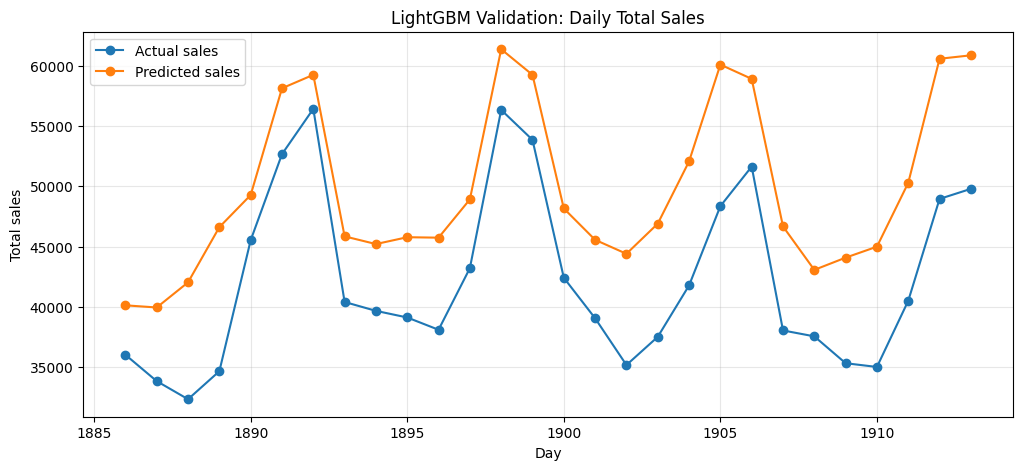

,d,actual_sales,predicted_sales
0,1886,36041.0,40141.117188
1,1887,33857.0,39962.503906
2,1888,32359.0,42047.109375
3,1889,34681.0,46621.515625
4,1890,45536.0,49283.257812
5,1891,52672.0,58131.582031
6,1892,56425.0,59246.968750
7,1893,40418.0,45856.992188
8,1894,39683.0,45219.500000
9,1895,39134.0,45786.582031


In [23]:
# LightGBM daily validation graph
lightgbm_daily_validation = (
    validation_predictions
    .groupby(TIME_COL, as_index=False)
    .agg(actual_sales=(TARGET_COL, 'sum'), predicted_sales=('prediction', 'sum'))
)

plt.figure(figsize=(12, 5))
plt.plot(lightgbm_daily_validation[TIME_COL], lightgbm_daily_validation['actual_sales'], marker='o', label='Actual sales')
plt.plot(lightgbm_daily_validation[TIME_COL], lightgbm_daily_validation['predicted_sales'], marker='o', label='Predicted sales')
plt.title('LightGBM Validation: Daily Total Sales')
plt.xlabel('Day')
plt.ylabel('Total sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lightgbm_daily_validation